## **Part1-DATA LOADING & DATA UNDERSTANDING**

In [1]:
#1.1 Import Required Libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#1.2 Load Data
data=pd.read_csv("../dataset/Final_Marks_Data.csv")

In [3]:
#1.3 Display Dataset Records 
data.head()

,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66


In [4]:
data.tail()

,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
1995,S2995,82,31,28,6,2,52
1996,S2996,78,38,27,7,2,57
1997,S2997,78,30,33,9,2,61
1998,S2998,82,29,40,8,3,59
1999,S2999,97,32,38,7,3,64


In [5]:
data.sample(5)

,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
872,S1872,81,30,33,7,3,58
76,S1076,77,33,32,6,3,65
1742,S2742,91,35,38,8,2,68
1533,S2533,76,30,32,9,3,62
193,S1193,83,37,33,7,4,72


In [6]:
#1.4 Display Dataset Information
print("Number of Rows:",data.shape[0])

Number of Rows: 2000


In [7]:
print("Number of Columns:",data.shape[1])

Number of Columns: 7


In [8]:
print("Column Names:")
print(data.columns.tolist())

Column Names:
['Student_ID', 'Attendance (%)', 'Internal Test 1 (out of 40)', 'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)', 'Daily Study Hours', 'Final Exam Marks (out of 100)']


In [9]:
print("Data Types:")
print(data.dtypes)

Data Types:
Student_ID                       object
Attendance (%)                    int64
Internal Test 1 (out of 40)       int64
Internal Test 2 (out of 40)       int64
Assignment Score (out of 10)      int64
Daily Study Hours                 int64
Final Exam Marks (out of 100)     int64
dtype: object


In [10]:
print("Non-Null Values:")
print(data.notnull().sum())

Non-Null Values:
Student_ID                       2000
Attendance (%)                   2000
Internal Test 1 (out of 40)      2000
Internal Test 2 (out of 40)      2000
Assignment Score (out of 10)     2000
Daily Study Hours                2000
Final Exam Marks (out of 100)    2000
dtype: int64


In [11]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64


In [12]:
#1.5 Dataset Shape
data.shape

(2000, 7)

In [13]:
#1.6 Identify Column Types
print("Numerical Column:")
print(data.select_dtypes(include='number').columns.tolist())

Numerical Column:
['Attendance (%)', 'Internal Test 1 (out of 40)', 'Internal Test 2 (out of 40)', 'Assignment Score (out of 10)', 'Daily Study Hours', 'Final Exam Marks (out of 100)']


In [14]:
print("Categorical Columns:")
print(data.select_dtypes(include='object').columns.tolist())

Categorical Columns:
['Student_ID']


In [15]:
print("Datetime Column")
print(data.select_dtypes(include='datetime').columns)

Datetime Column
Index([], dtype='object')


## **PART2-DATA CLEANING & PREPROCESSING**

In [16]:
#2.1 Check Missing Values
Missing_values=data.isnull().sum()
Missing_values

Student_ID                       0
Attendance (%)                   0
Internal Test 1 (out of 40)      0
Internal Test 2 (out of 40)      0
Assignment Score (out of 10)     0
Daily Study Hours                0
Final Exam Marks (out of 100)    0
dtype: int64

In [17]:
Missing_percentage=(data.isnull().sum()/len(data))*100
Missing_percentage

Student_ID                       0.0
Attendance (%)                   0.0
Internal Test 1 (out of 40)      0.0
Internal Test 2 (out of 40)      0.0
Assignment Score (out of 10)     0.0
Daily Study Hours                0.0
Final Exam Marks (out of 100)    0.0
dtype: float64

In [18]:
Missing_summary=pd.DataFrame({
    "Missing Values":Missing_values,
    "Missing Percentage":Missing_percentage})
Missing_summary

,Missing Values,Missing Percentage
Student_ID,0,0.0
Attendance (%),0,0.0
Internal Test 1 (out of 40),0,0.0
Internal Test 2 (out of 40),0,0.0
Assignment Score (out of 10),0,0.0
Daily Study Hours,0,0.0
Final Exam Marks (out of 100),0,0.0


In [19]:
#2.2 Handle Missing Values
Missing_values=data.isnull().sum()
if Missing_values.sum()==0:
    print("No missing values found. No imputation or row/column removal is required.")
else:
    print("Missing values required handling.")

No missing values found. No imputation or row/column removal is required.


In [20]:
#2.3 Check Duplicate Records
data.duplicated().sum()

np.int64(0)

In [21]:
data=data.drop_duplicates()
data

,Student_ID,Attendance (%),Internal Test 1 (out of 40),Internal Test 2 (out of 40),Assignment Score (out of 10),Daily Study Hours,Final Exam Marks (out of 100)
0,S1000,84,30,36,7,3,72
1,S1001,91,24,38,6,3,56
2,S1002,73,29,26,7,3,56
3,S1003,80,36,35,7,3,74
4,S1004,84,31,37,8,3,66
...,...,...,...,...,...,...,...
1995,S2995,82,31,28,6,2,52
1996,S2996,78,38,27,7,2,57
1997,S2997,78,30,33,9,2,61
1998,S2998,82,29,40,8,3,59


In [22]:
data.duplicated().sum()

np.int64(0)

In [23]:
#2.4 Check Data TYpes
data.dtypes

Student_ID                       object
Attendance (%)                    int64
Internal Test 1 (out of 40)       int64
Internal Test 2 (out of 40)       int64
Assignment Score (out of 10)      int64
Daily Study Hours                 int64
Final Exam Marks (out of 100)     int64
dtype: object

## Data type observation
Student ID is stored as an object because it is an identifier. The other columns are numerical and suitable for analysis.

In [24]:
#2.5 Rename Columns
data.columns.tolist()

['Student_ID',
 'Attendance (%)',
 'Internal Test 1 (out of 40)',
 'Internal Test 2 (out of 40)',
 'Assignment Score (out of 10)',
 'Daily Study Hours',
 'Final Exam Marks (out of 100)']

In [25]:
data=data.rename(columns={
                         "Student ID": "Student_ID",
                          "Attendance (%)":"Attendance_Percent",
                          "Internal Test 1 (out of 40)":"Internal_Test_1",
                          "Internal Test 2 (out of 40)":"Internal_Test_2",
                          "Assignment Score (out of 10)":"Assignment_Score",
                          "Daily Study Hours":"Daily_Study_Hours",
                          "Final Exam Marks (out of 100)":"Final_Exam_Marks"
                         })

In [26]:
data.columns

Index(['Student_ID', 'Attendance_Percent', 'Internal_Test_1',
       'Internal_Test_2', 'Assignment_Score', 'Daily_Study_Hours',
       'Final_Exam_Marks'],
      dtype='object')

## Interpretation
The column names were renamed to shorter and Python-friendly names.This makes the dataset easier to work with 
during data analysis and machine learning.

In [27]:
#2.6 Check Invalid Values
data.min()

Student_ID            S1000
Attendance_Percent       52
Internal_Test_1          18
Internal_Test_2          16
Assignment_Score          4
Daily_Study_Hours         1
Final_Exam_Marks         25
dtype: object

In [28]:
data.max()

Student_ID            S2999
Attendance_Percent      100
Internal_Test_1          40
Internal_Test_2          40
Assignment_Score         10
Daily_Study_Hours         5
Final_Exam_Marks        100
dtype: object

## Interpretation
No invalid values were found in the dataset.All numerical values were within a reasonable range, 
and the Student ID followed a valid format.

In [29]:
#2.7 Verify the Cleaned Dataset 
data.isnull().sum()

Student_ID            0
Attendance_Percent    0
Internal_Test_1       0
Internal_Test_2       0
Assignment_Score      0
Daily_Study_Hours     0
Final_Exam_Marks      0
dtype: int64

In [30]:
data.duplicated().sum()

np.int64(0)

In [31]:
data.dtypes

Student_ID            object
Attendance_Percent     int64
Internal_Test_1        int64
Internal_Test_2        int64
Assignment_Score       int64
Daily_Study_Hours      int64
Final_Exam_Marks       int64
dtype: object

In [32]:
data.shape

(2000, 7)

In [33]:
data.describe()

,Attendance_Percent,Internal_Test_1,Internal_Test_2,Assignment_Score,Daily_Study_Hours,Final_Exam_Marks
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,84.891500,32.115500,32.464500,7.507000,2.823500,64.855000
std,7.758855,4.563504,4.522827,1.021015,0.608714,11.341265
min,52.000000,18.000000,16.000000,4.000000,1.000000,25.000000
25%,80.000000,29.000000,29.000000,7.000000,2.000000,58.000000
50%,85.000000,32.000000,33.000000,8.000000,3.000000,65.000000
75%,90.000000,35.000000,36.000000,8.000000,3.000000,73.000000
max,100.000000,40.000000,40.000000,10.000000,5.000000,100.000000


## **PART3-EXPLORATORY DATA ANALYSIS(EDA)**

In [34]:
#3.1 Descriptive Statistics
data.mean(numeric_only=True)

Attendance_Percent    84.8915
Internal_Test_1       32.1155
Internal_Test_2       32.4645
Assignment_Score       7.5070
Daily_Study_Hours      2.8235
Final_Exam_Marks      64.8550
dtype: float64

In [35]:
data.median(numeric_only=True)

Attendance_Percent    85.0
Internal_Test_1       32.0
Internal_Test_2       33.0
Assignment_Score       8.0
Daily_Study_Hours      3.0
Final_Exam_Marks      65.0
dtype: float64

In [36]:
data.mode(numeric_only=True)

,Attendance_Percent,Internal_Test_1,Internal_Test_2,Assignment_Score,Daily_Study_Hours,Final_Exam_Marks
0,86,32,35,8,3,66


In [37]:
data.min(numeric_only=True)

Attendance_Percent    52
Internal_Test_1       18
Internal_Test_2       16
Assignment_Score       4
Daily_Study_Hours      1
Final_Exam_Marks      25
dtype: int64

In [38]:
data.max(numeric_only=True)

Attendance_Percent    100
Internal_Test_1        40
Internal_Test_2        40
Assignment_Score       10
Daily_Study_Hours       5
Final_Exam_Marks      100
dtype: int64

In [39]:
data.max(numeric_only=True)-data.min(numeric_only=True)

Attendance_Percent    48
Internal_Test_1       22
Internal_Test_2       24
Assignment_Score       6
Daily_Study_Hours      4
Final_Exam_Marks      75
dtype: int64

In [40]:
data.std(numeric_only=True)

Attendance_Percent     7.758855
Internal_Test_1        4.563504
Internal_Test_2        4.522827
Assignment_Score       1.021015
Daily_Study_Hours      0.608714
Final_Exam_Marks      11.341265
dtype: float64

In [41]:
data.var(numeric_only=True)

Attendance_Percent     60.199828
Internal_Test_1        20.825573
Internal_Test_2        20.455968
Assignment_Score        1.042472
Daily_Study_Hours       0.370533
Final_Exam_Marks      128.624287
dtype: float64

In [42]:
#3.6 Correlation Analysis
correlation=data.select_dtypes(include=np.number).corr()
correlation

,Attendance_Percent,Internal_Test_1,Internal_Test_2,Assignment_Score,Daily_Study_Hours,Final_Exam_Marks
Attendance_Percent,1.000000,0.505033,0.494560,0.432373,0.298767,0.725644
Internal_Test_1,0.505033,1.000000,0.263400,0.568047,0.213539,0.689227
Internal_Test_2,0.494560,0.263400,1.000000,0.541970,0.225670,0.691049
Assignment_Score,0.432373,0.568047,0.541970,1.000000,0.169005,0.669400
Daily_Study_Hours,0.298767,0.213539,0.225670,0.169005,1.000000,0.412877
Final_Exam_Marks,0.725644,0.689227,0.691049,0.669400,0.412877,1.000000


# 3.2 Mean
The mean represents the average value of a numerical variable. In this dataset, the mean helps us understand the average
attendance, test scores,assignment score, daily study hours, and final exam marks.The mean values obtained from the dataset 
are reported in the output above.

# 3.3 Median
The median represents the middle value of the data when the observations are arranged in ascending order. It is less 
affected by extreme values than the mean. The median values obtained from the dataset as shown in the descriptive
statistics results above.

# 3.4 Mode
The mode represents the most frequently occurring value in a dataset.The mode values obtained from the numerical 
columns were identified during the descriptive statistics analysis.It helps is understand the values that occur 
most frequently among the students.

# 3.5 Standard Deviation

Standard deviation measures how much the values vary around their mean. A higher standard deviation indicates greater variation in the data, while a lower standard deviation indicates that the values are closer to the mean. The standard deviation values obtained from the dataset were calculated during the descriptive statistics analysis.

# 3.6 Correlation Analysis
A correlation matrix was created for the suitable numerical variables in the dataset. The correlation coefficient ranges from -1 to +1, where +1 indicates a perfect positive correlation, 0 indicates no linear correlation, and -1 indicates a perfect negative correlation.
The analysis shows that Attendance_Percent has the strongest positive correlation with Final_Exam_Marks (0.73). Internal_Test_1 (0.69), Internal_Test_2 (0.69), and Assignment_Score (0.67) also show strong positive relationships with final exam marks. Daily_Study_Hours has a weaker but still positive correlation with Final_Exam_Marks (0.41). Overall, the results indicate that students with higher attendance, better internal test scores, and higher assignment scores generally tend to achieve higher final exam marks.

# **PART4-DATA VISUALIZATION**

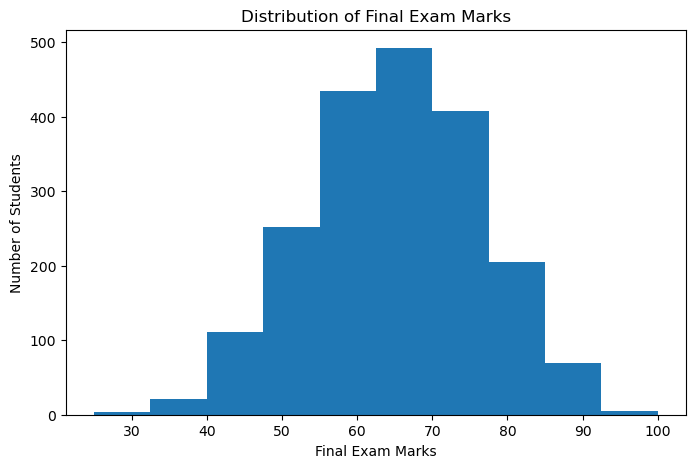

In [62]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(data["Final_Exam_Marks"],bins=10)
plt.title("Distribution of Final Exam Marks")
plt.xlabel("Final Exam Marks")
plt.ylabel("Number of Students")
plt.savefig("../images/visualization_01.png",bbox_inches="tight")
plt.show()

# Interpretation
The histogram shows that most students scored between 55 and 80 marks. The highest concentration of students is around 65–70 marks.

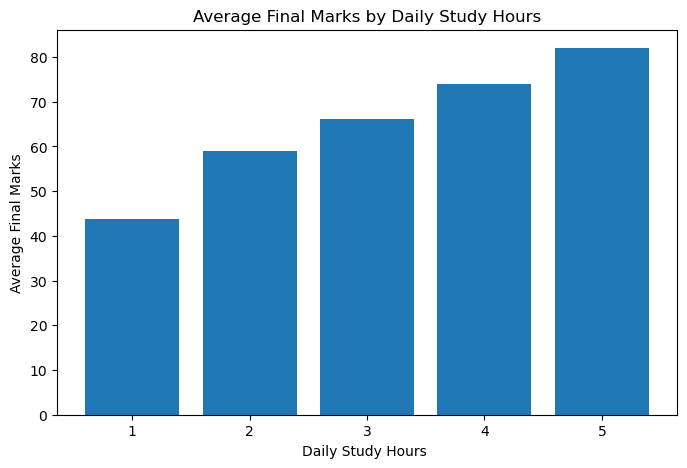

In [61]:
# Bar chart
avg_marks=data.groupby("Daily_Study_Hours")["Final_Exam_Marks"].mean()
plt.figure(figsize=(8,5))
plt.bar(avg_marks.index,avg_marks.values)
plt.title("Average Final Marks by Daily Study Hours")
plt.xlabel("Daily Study Hours ")
plt.ylabel("Average Final Marks")
plt.savefig("../images/visualization_02.png",bbox_inches="tight")
plt.show()

# Interpretation
The bar chart shows that average final exam marks increase as daily study hours increase. Students who study more 
generally achieve higher average marks.

In [45]:
# Pie Chart
data["Performance_Level"]=pd.cut(
    data["Final_Exam_Marks"],
    bins=[0,49,69,100],
    labels=["Low","Average","High"]
)

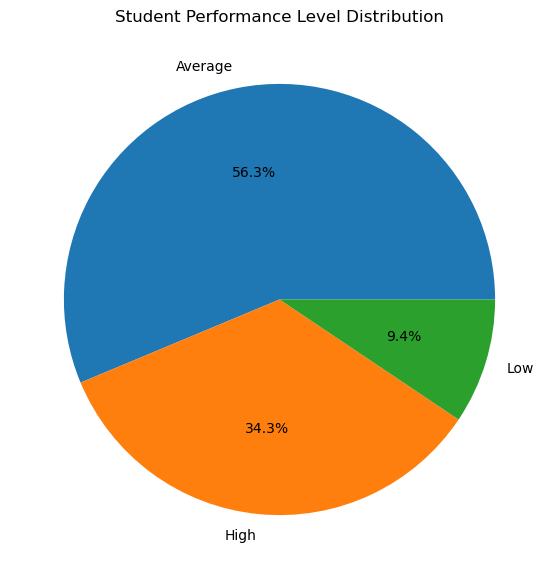

In [60]:
performance_counts=data["Performance_Level"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    performance_counts,
    labels=performance_counts.index,
    autopct="%1.1f%%"
)
plt.title("Student Performance Level Distribution")
plt.savefig("../images/visualization_03.png",bbox_inches="tight")
plt.show()

# Interpretation
The pie chart shows that most students are in the Average performance category (56.3%). The High category represents 34.3% of students, while the Low category represents 9.4%.

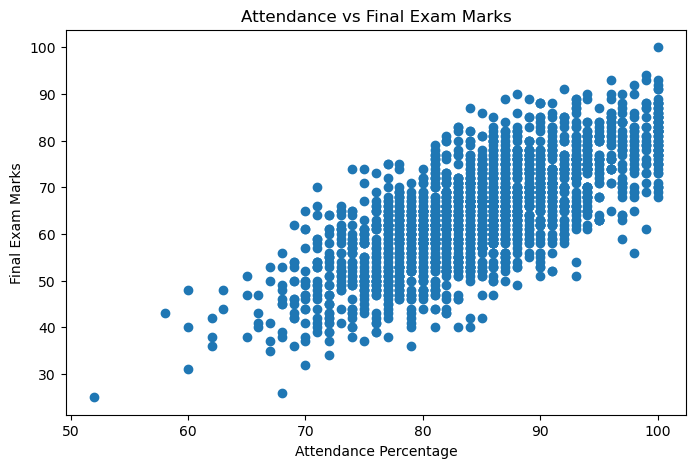

In [59]:
# Scatter Plot
plt.figure(figsize=(8,5))
plt.scatter(data["Attendance_Percent"],
            data["Final_Exam_Marks"])
plt.title("Attendance vs Final Exam Marks")
plt.xlabel("Attendance Percentage")
plt.ylabel("Final Exam Marks")
plt.savefig("../images/visualization_04.png",bbox_inches="tight")
plt.show()

# Interpretation
The scatter plot shows a positive relationship between attendance and final exam marks. Students with higher attendance generally tend to achieve higher marks.

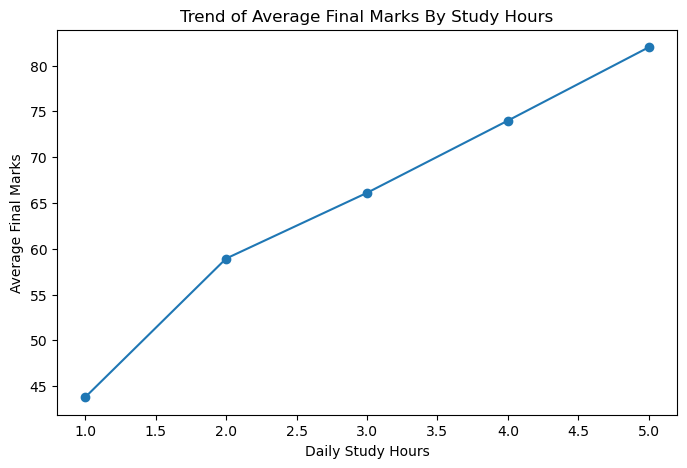

In [58]:
# Line Chart
plt.figure(figsize=(8,5))
plt.plot(avg_marks.index,
         avg_marks.values,
         marker="o")
plt.title("Trend of Average Final Marks By Study Hours")
plt.xlabel("Daily Study Hours")
plt.ylabel("Average Final Marks")
plt.savefig("../images/visualization_05.png",bbox_inches="tight")
plt.show()

# Interpretation
The line chart shows an increasing trend in average final exam marks as daily study hours increase. This indicates that higher study time is associated with better academic performance.

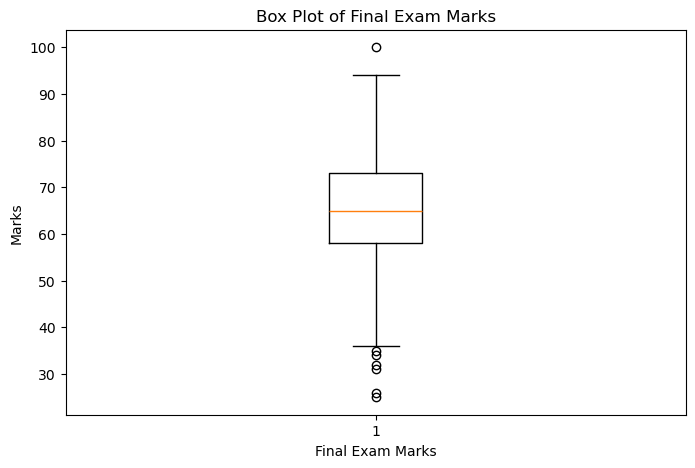

In [57]:
# Box Plot
plt.figure(figsize=(8,5))
plt.boxplot(data["Final_Exam_Marks"])
plt.title("Box Plot of Final Exam Marks")
plt.xlabel("Final Exam Marks")
plt.ylabel("Marks")
plt.savefig("../images/visualization_06.png",bbox_inches="tight")
plt.show()

# Interpretation
The box plot shows a median of approximately 65 marks and an interquartile range from about 55 to 73. Some possible outliers are visible at the lower and higher ends.

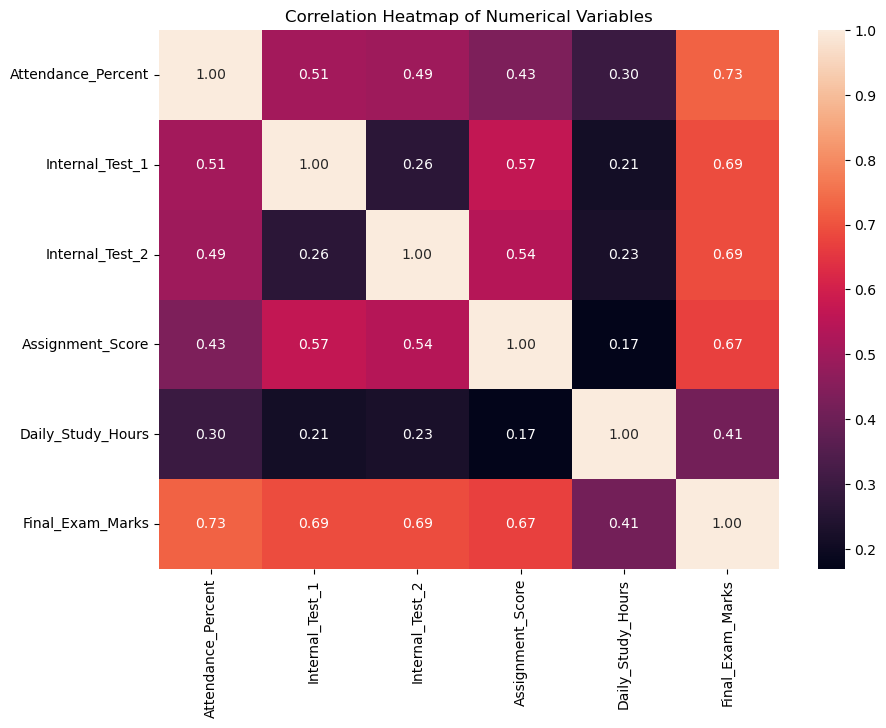

In [56]:
# Correlation Heatmap
correlation=data.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10,7))
sns.heatmap(correlation,
            annot=True,
            fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.savefig("../images/visualization_07.png",bbox_inches="tight")
plt.show()

# Interpretation
Attendance (0.73) and internal tests (0.69) show the strongest relationships with Final Exam Marks. Daily Study Hours (0.41) show a weaker relationship with final exam marks.

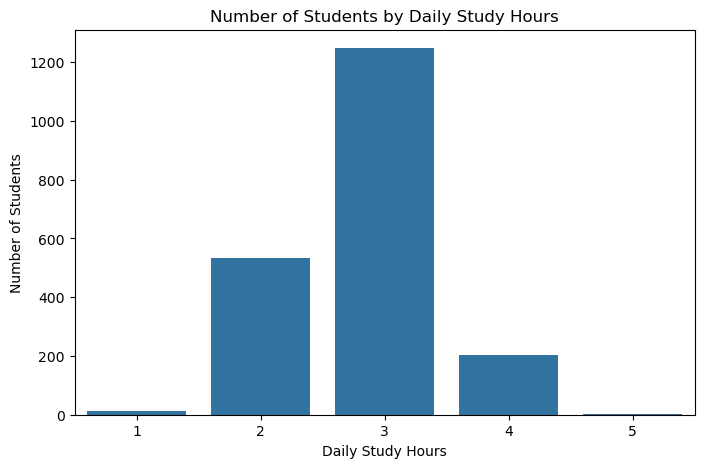

In [55]:
#4.8 Count Plot
plt.figure(figsize=(8,5))
sns.countplot(data=data,
              x="Daily_Study_Hours")
plt.title("Number of Students by Daily Study Hours")
plt.xlabel("Daily Study Hours")
plt.ylabel("Number of Students")
plt.savefig("../images/visualization_08.png",bbox_inches="tight")
plt.show()

# Interpretation
Most students study 3 hours daily, followed by 2 hours. Very few students study for 1 hour or 4 or more hours per day.

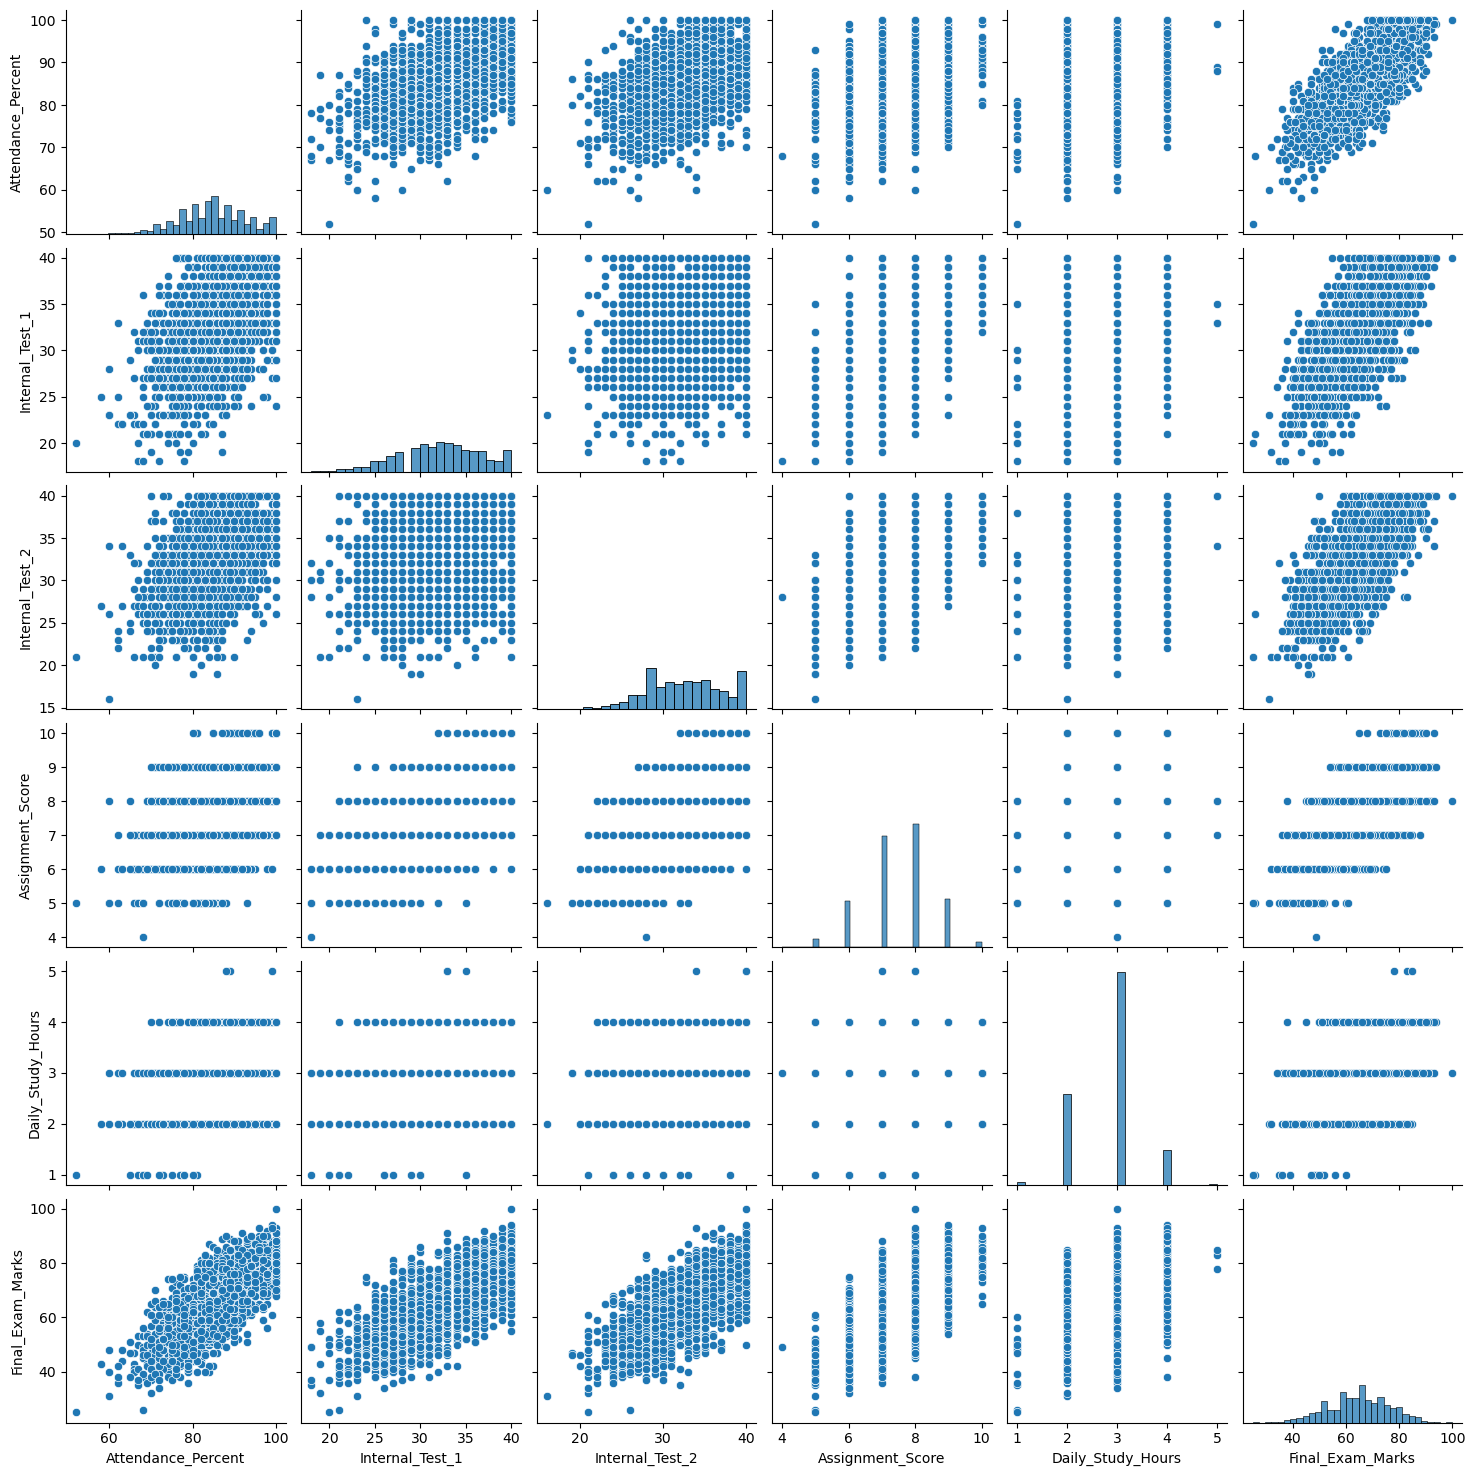

In [63]:
#4.9 Pair Plot
pair_data=data[
    ["Attendance_Percent",
     "Internal_Test_1",
     "Internal_Test_2",
     "Assignment_Score",
     "Daily_Study_Hours",
     "Final_Exam_Marks"
    ]
 ]
sns.pairplot(pair_data)
plt.savefig("../images/visualization_09.png",bbox_inches="tight")
plt.show()

## Interpretation
The pairplot shows positive relationships among attendance, internal test scores,assignment scores, daily study hours,
and final exam marks. The upward trends indicate that higher values of these variables are 
generally associated with higher final exam marks. The diagonal plots show the distribution of each variable.

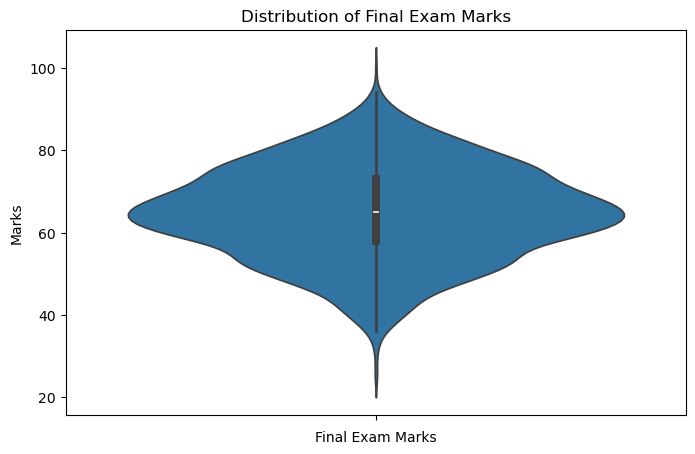

In [64]:
#4.10 Violin Plot
plt.figure(figsize=(8,5))
sns.violinplot(y=data["Final_Exam_Marks"])
plt.title("Distribution of Final Exam Marks")
plt.xlabel("Final Exam Marks")
plt.ylabel("Marks")
plt.savefig("../images/visualization_10.png",bbox_inches="tight")
plt.show()

# Interpretation
The violin plot shows the distribution of Final Exam Marks.The distribution is centered around a 
median of approximately 65, with most students concentrated around the average score range.

# PART5-DATA INSIGHTS & FINDINGS

1.**Average Final Exam Marks:** The average is 64.86, with a median of 65.                                                                             
   
2.**Final Exam Range:** Marks range from 25 to 100.
   
3.**Average Attendance:** Average attendance is 84.89%, ranging from 52% to 100%.                                                                      
    
4.**Internal Tests:** Average scores are 32.12/40 in Test 1 and 32.46/40 in Test 2.                                                                    
   
5.**Assignment Score:** The average assignment score is 7.51/10.                                                                                       
   
6.**Daily Study Hours:** Students study 2.82 hours per day on average.                                                                                 
   
7.**Study Hours Trend:** More study hours are associated with higher average final marks.                                                              
   
8.**Attendance Trend:** Higher attendance is generally associated with higher final exam marks.                                                        

9.**Performance Distribution:** 56.3% of students are in the Average category, 34.3% in the High category, and 9.4% in the Low category.               

10.**Most Common Mark:** The most frequently occurring Final Exam Mark is 66.                                                                          

11.**Mark Distribution:** Most final marks are concentrated around 55–80.                                                                              

12.**Overall Finding:** Regular attendance and more study time are positively associated with better performance.                                          

# **PART6-FINAL CONCLUSION**

This project analyzed a dataset of 2,000 student records to understand student academic performance. The dataset included attendance, internal test scores, assignment scores, daily study hours, and final exam marks. The data was cleaned by checking missing values, duplicate records, data types, column names, and invalid values, followed by verification of the cleaned dataset. Exploratory and statistical analysis was performed using mean, median, mode, minimum, maximum, range, standard deviation, variance, and correlation analysis. Different visualizations, including histograms, bar charts, pie charts, scatter plots, line charts, correlation heatmaps, pairplots, violin plots, and box plots, were created to identify patterns and relationships in the data.

The analysis showed that attendance and internal test scores had strong positive relationships with final exam marks, while daily study hours also showed a positive relationship with performance. Most students were in the Average performance category, and final exam marks were mainly concentrated around the middle range. Through this project, I learned how to load, clean, analyze, visualize, and interpret real-world student data using Python and its data analysis libraries. This type of analysis can be useful in educational settings to understand student performance, identify important factors affecting results, and support better academic planning and decision-making.